In [17]:
import os
import random
import time
import copy
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu130


In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [19]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [20]:
!wget -q -O /content/plantvillage.zip \
https://www.kaggle.com/api/v1/datasets/download/abdallahalidev/plantvillage-dataset

In [21]:
import os
import zipfile

ZIP_PATH = "/content/plantvillage.zip"
EXTRACT_PATH = "/content/plantvillage"

if not os.path.exists(EXTRACT_PATH):

    print("Extracting dataset...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_PATH
        )

    print("Extraction completed.")

else:

    print("Dataset already extracted.")

Dataset already extracted.


In [22]:
COLOR_DIR = None

for root, dirs, files in os.walk(EXTRACT_PATH):

    if "color" in dirs:

        COLOR_DIR = os.path.join(
            root,
            "color"
        )

        break


print("Dataset directory:")
print(COLOR_DIR)

Dataset directory:
/content/plantvillage/plantvillage dataset/color


In [23]:
assert COLOR_DIR is not None, \
    "Could not find the color dataset folder."

assert os.path.exists(COLOR_DIR), \
    "Dataset folder does not exist."

print("✓ Dataset path is valid")

✓ Dataset path is valid


In [24]:
dataset = datasets.ImageFolder(
    COLOR_DIR
)

print(
    "Total images:",
    len(dataset)
)

print(
    "Number of classes:",
    len(dataset.classes)
)

Total images: 54305
Number of classes: 38


In [25]:
class_names = dataset.classes

for i, class_name in enumerate(
    class_names
):

    print(
        f"{i:2d}: {class_name}"
    )

 0: Apple___Apple_scab
 1: Apple___Black_rot
 2: Apple___Cedar_apple_rust
 3: Apple___healthy
 4: Blueberry___healthy
 5: Cherry_(including_sour)___Powdery_mildew
 6: Cherry_(including_sour)___healthy
 7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 8: Corn_(maize)___Common_rust_
 9: Corn_(maize)___Northern_Leaf_Blight
10: Corn_(maize)___healthy
11: Grape___Black_rot
12: Grape___Esca_(Black_Measles)
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14: Grape___healthy
15: Orange___Haunglongbing_(Citrus_greening)
16: Peach___Bacterial_spot
17: Peach___healthy
18: Pepper,_bell___Bacterial_spot
19: Pepper,_bell___healthy
20: Potato___Early_blight
21: Potato___Late_blight
22: Potato___healthy
23: Raspberry___healthy
24: Soybean___healthy
25: Squash___Powdery_mildew
26: Strawberry___Leaf_scorch
27: Strawberry___healthy
28: Tomato___Bacterial_spot
29: Tomato___Early_blight
30: Tomato___Late_blight
31: Tomato___Leaf_Mold
32: Tomato___Septoria_leaf_spot
33: Tomato___Spider_mites Two-spotte

In [26]:
IMG_SIZE = 256

NUM_CLASSES = 38

BATCH_SIZE = 32

LEARNING_RATE = 0.001

EPOCHS = 5

DROPOUT = 0.5

WEIGHT_DECAY = 1e-4

In [75]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [28]:
eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


In [29]:
targets = np.array(
    dataset.targets
)

indices = np.arange(
    len(dataset)
)

In [30]:
train_indices, temp_indices = train_test_split(

    indices,

    test_size=0.30,

    stratify=targets,

    random_state=SEED
)

In [31]:
temp_targets = targets[
    temp_indices
]

val_indices, test_indices = train_test_split(

    temp_indices,

    test_size=0.50,

    stratify=temp_targets,

    random_state=SEED
)

In [32]:
print(
    "Training:",
    len(train_indices)
)

print(
    "Validation:",
    len(val_indices)
)

print(
    "Testing:",
    len(test_indices)
)

print()

print(
    "Training %:",
    len(train_indices)
    / len(dataset) * 100
)

print(
    "Validation %:",
    len(val_indices)
    / len(dataset) * 100
)

print(
    "Testing %:",
    len(test_indices)
    / len(dataset) * 100
)

Training: 38013
Validation: 8146
Testing: 8146

Training %: 69.99907927446827
Validation %: 15.00046036276586
Testing %: 15.00046036276586


In [76]:
train_dataset_full = datasets.ImageFolder(
    COLOR_DIR,
    transform=train_transform
)

eval_dataset_full = datasets.ImageFolder(
    COLOR_DIR,
    transform=eval_transform
)

In [77]:
train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    eval_dataset_full,
    val_indices
)

test_dataset = Subset(
    eval_dataset_full,
    test_indices
)

In [78]:
print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 38013
Validation: 8146
Test: 8146


In [79]:
train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

print("✓ DataLoaders ready")

✓ DataLoaders ready


In [37]:
def denormalize(image):

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(
        image,
        0,
        1
    )

Image batch shape: torch.Size([32, 3, 256, 256])
Label batch shape: torch.Size([32])


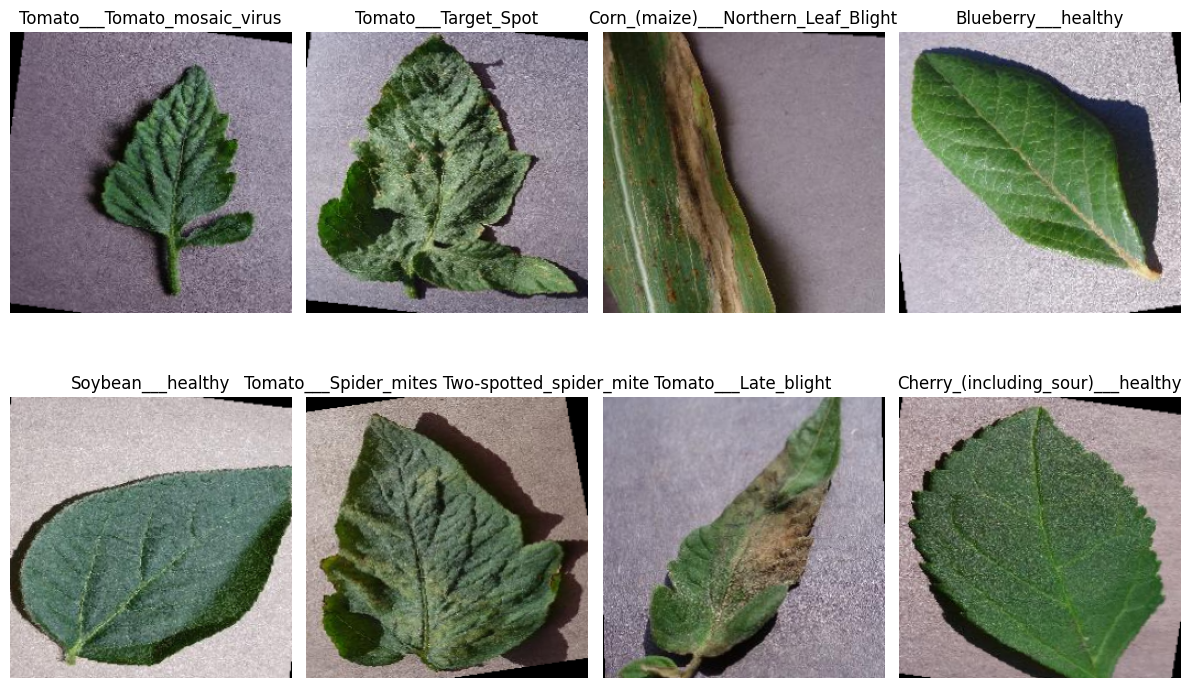

In [39]:
# ==========================================
# STEP 16 — Check and display sample images
# ==========================================

# Get one batch from the training loader
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Expected:
# Image batch shape: torch.Size([32, 3, 256, 256])
# Label batch shape: torch.Size([32])


# ==========================================
# Denormalization function
# ==========================================

def denormalize(image):

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(
        image,
        0,
        1
    )


# ==========================================
# Display 8 images
# ==========================================

plt.figure(figsize=(12, 8))

for i in range(8):

    image = denormalize(images[i])

    image = image.permute(1, 2, 0)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(
        class_names[labels[i].item()]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [80]:
class SEBlock(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        reduced_channels = max(
            channels // reduction,
            1
        )

        self.pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(

            nn.Linear(
                channels,
                reduced_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                reduced_channels,
                channels
            ),

            nn.Sigmoid()
        )


    def forward(self, x):

        batch_size = x.size(0)

        channels = x.size(1)

        y = self.pool(x)

        y = y.view(
            batch_size,
            channels
        )

        y = self.fc(y)

        y = y.view(
            batch_size,
            channels,
            1,
            1
        )

        return x * y

In [41]:
class DepthwiseSeparableConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=1,
            groups=in_channels,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            in_channels
        )

        self.relu1 = nn.ReLU(
            inplace=True
        )

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            out_channels
        )

        self.relu2 = nn.ReLU(
            inplace=True
        )

    def forward(self, x):

        x = self.depthwise(x)

        x = self.bn1(x)

        x = self.relu1(x)

        x = self.pointwise(x)

        x = self.bn2(x)

        x = self.relu2(x)

        return x

In [88]:
class BasePaperCNN(nn.Module):

    def __init__(self, num_classes=38):

        super().__init__()

        # =====================================
        # BLOCK 1
        # 3 -> 32
        # =====================================

        self.block1 = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )


        # =====================================
        # BLOCK 2
        # 32 -> 64
        # =====================================

        self.conv2 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )


        # SE Block 2

        self.se2 = SEBlock(64)


        # Residual 32 -> 64
        # stride=2 because Block 2 downsamples

        self.residual2 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=1,
                stride=2,
                bias=False
            ),

            nn.BatchNorm2d(64)
        )


        # =====================================
        # BLOCK 3
        # 64 -> 128
        # Depthwise Separable Convolution
        # =====================================

        self.conv3 = DepthwiseSeparableConv(
            64,
            128
        )


        # SE Block 3

        self.se3 = SEBlock(128)


        # Residual 64 -> 128

        self.residual3 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(128)
        )


        # =====================================
        # FEATURE FUSION
        # 32 + 64 + 128 = 224
        # =====================================

        self.fusion_channels = 224


        # =====================================
        # ATTENTION
        # =====================================

        self.attention = nn.Sequential(

            nn.Conv2d(
                224,
                224,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(224),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                224,
                224,
                kernel_size=1
            ),

            nn.Sigmoid()
        )


        # =====================================
        # GLOBAL AVERAGE POOLING
        # =====================================

        self.gap = nn.AdaptiveAvgPool2d(1)


        # =====================================
        # CLASSIFIER
        # =====================================

        self.fc1 = nn.Linear(
            224,
            256
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.dropout = nn.Dropout(
            p=0.5
        )

        self.fc2 = nn.Linear(
            256,
            num_classes
        )


    def forward(self, x):

        # =====================================
        # BLOCK 1
        # =====================================

        f1 = self.block1(x)


        # =====================================
        # BLOCK 2 + RESIDUAL
        # =====================================

        residual2 = self.residual2(f1)

        f2 = self.conv2(f1)

        f2 = f2 + residual2

        f2 = torch.relu(f2)

        f2 = self.se2(f2)


        # =====================================
        # BLOCK 3 + RESIDUAL
        # =====================================

        residual3 = self.residual3(f2)

        f3 = self.conv3(f2)

        f3 = f3 + residual3

        f3 = torch.relu(f3)

        f3 = self.se3(f3)


        # =====================================
        # FEATURE FUSION
        # =====================================

        f1_resized = nn.functional.adaptive_avg_pool2d(
            f1,
            f3.shape[-2:]
        )

        f2_resized = nn.functional.adaptive_avg_pool2d(
            f2,
            f3.shape[-2:]
        )

        fused = torch.cat(
            [
                f1_resized,
                f2_resized,
                f3
            ],
            dim=1
        )


        # =====================================
        # ATTENTION
        # =====================================

        attention_map = self.attention(
            fused
        )

        fused = fused * attention_map


        # =====================================
        # GLOBAL AVERAGE POOLING
        # =====================================

        x = self.gap(fused)

        x = torch.flatten(
            x,
            1
        )


        # =====================================
        # FC 256
        # =====================================

        x = self.fc1(x)

        x = self.relu(x)


        # =====================================
        # DROPOUT
        # =====================================

        x = self.dropout(x)


        # =====================================
        # 38 CLASS OUTPUT
        # =====================================

        x = self.fc2(x)

        return x

In [89]:
model = BasePaperCNN(
    num_classes=NUM_CLASSES
).to(device)

print("Model created successfully.")

Model created successfully.


In [90]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_parameters:,}"
)

print(
    f"Trainable parameters: {trainable_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters / 1e6:.3f} M"
)

Total parameters: 210,418
Trainable parameters: 210,418
Trainable parameters: 0.210 M


In [91]:
model.eval()

dummy_input = torch.randn(
    2,
    3,
    256,
    256
).to(device)

with torch.no_grad():

    output = model(
        dummy_input
    )

print("Input shape :", dummy_input.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 38])


In [92]:
criterion = nn.CrossEntropyLoss()

In [93]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [94]:
EPOCHS = 5
PATIENCE = 2

best_val_accuracy = 0.0
best_model_state = None
patience_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [95]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        _,
        _,
        _
    ) = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )

    elapsed = (
        time.time() - start_time
    ) / 60

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_acc:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_acc:.2f}%"
    )

    print(
        f"Time: {elapsed:.2f} minutes"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        print("✓ Best model saved")

    else:

        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

    if patience_counter >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break


Epoch 1/5


Training:   0%|          | 0/1188 [00:00<?, ?it/s]

Train Loss: 1.6518
Train Accuracy: 52.38%
Validation Loss: 0.8148
Validation Accuracy: 75.07%
Time: 3.37 minutes
✓ Best model saved

Epoch 2/5


Training:   0%|          | 0/1188 [00:00<?, ?it/s]

Train Loss: 0.8571
Train Accuracy: 73.71%
Validation Loss: 0.5123
Validation Accuracy: 84.40%
Time: 3.39 minutes
✓ Best model saved

Epoch 3/5


...

Training:   0%|          | 0/1188 [00:00<?, ?it/s]

Train Loss: 0.4996
Train Accuracy: 84.22%
Validation Loss: 0.3751
Validation Accuracy: 87.47%
Time: 3.38 minutes
No improvement (1/2)

Epoch 5/5


Training:   0%|          | 0/1188 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fea25af37e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fea25af37e0>
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Train Loss: 0.4172
Train Accuracy: 86.56%
Validation Loss: 0.2990
Validation Accuracy: 90.45%
Time: 3.39 minutes
✓ Best model saved


In [96]:
def validate(

    model,

    loader,

    criterion,

    device

):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0


    all_labels = []

    all_predictions = []

    all_probabilities = []


    with torch.no_grad():


        for images, labels in loader:


            images = images.to(

                device,

                non_blocking=True
            )


            labels = labels.to(

                device,

                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(

                outputs,

                labels
            )


            probabilities = torch.softmax(

                outputs,

                dim=1
            )


            _, predictions = torch.max(

                outputs,

                1
            )


            running_loss += (

                loss.item()
                * images.size(0)
            )


            total += labels.size(0)


            correct += (

                predictions == labels

            ).sum().item()


            all_labels.extend(

                labels.cpu().numpy()
            )


            all_predictions.extend(

                predictions.cpu().numpy()
            )


            all_probabilities.append(

                probabilities.cpu().numpy()
            )


    epoch_loss = (
        running_loss / total
    )


    epoch_accuracy = (
        correct / total
    ) * 100


    all_labels = np.array(
        all_labels
    )


    all_predictions = np.array(
        all_predictions
    )


    all_probabilities = np.concatenate(

        all_probabilities,

        axis=0
    )


    return (

        epoch_loss,

        epoch_accuracy,

        all_labels,

        all_predictions,

        all_probabilities
    )

In [98]:
model.load_state_dict(
    best_model_state
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

Best validation accuracy: 90.45%


In [100]:
(
    test_loss,
    test_accuracy,
    y_true,
    y_pred,
    y_prob
) = validate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Loss: 0.2747
Test Accuracy: 91.59%


In [101]:
checkpoint = {

    "model_state_dict":
        model.state_dict(),

    "optimizer_state_dict":
        optimizer.state_dict(),

    "class_names":
        class_names,

    "best_val_accuracy":
        best_val_accuracy,

    "history":
        history,

    "train_indices":
        train_indices,

    "val_indices":
        val_indices,

    "test_indices":
        test_indices
}


torch.save(

    checkpoint,

    "/content/base_paper_cnn_checkpoint.pth"
)


print(
    "✓ Checkpoint saved"
)

✓ Checkpoint saved


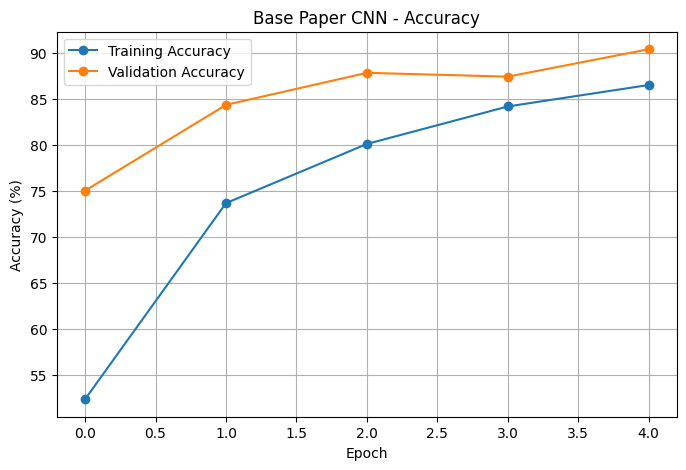

In [102]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(

    history["train_acc"],

    marker="o",

    label="Training Accuracy"
)

plt.plot(

    history["val_acc"],

    marker="o",

    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Base Paper CNN - Accuracy"
)

plt.legend()

plt.grid()

plt.show()

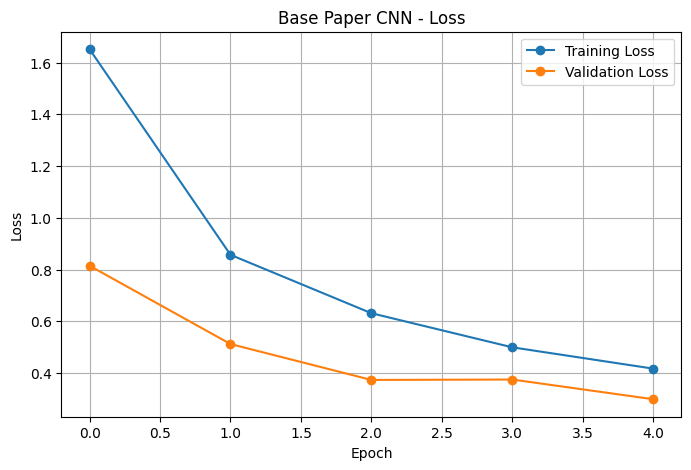

In [103]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(

    history["train_loss"],

    marker="o",

    label="Training Loss"
)

plt.plot(

    history["val_loss"],

    marker="o",

    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Base Paper CNN - Loss"
)

plt.legend()

plt.grid()

plt.show()

In [104]:
(
    test_loss,

    test_accuracy,

    y_true,

    y_pred,

    y_prob

) = validate(

    model,

    test_loader,

    criterion,

    device
)


print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy:.2f}%"
)

Test Loss: 0.2747
Test Accuracy: 91.59%


In [105]:
precision = precision_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0
)


recall = recall_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0
)


f1 = f1_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0
)


print(
    f"Macro Precision: "
    f"{precision:.4f}"
)

print(
    f"Macro Recall: "
    f"{recall:.4f}"
)

print(
    f"Macro F1-score: "
    f"{f1:.4f}"
)

Macro Precision: 0.8984
Macro Recall: 0.8904
Macro F1-score: 0.8890


In [106]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names,

        zero_division=0
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.88      0.87      0.88        94
                                 Apple___Black_rot       0.98      0.85      0.91        93
                          Apple___Cedar_apple_rust       0.87      0.95      0.91        41
                                   Apple___healthy       0.93      0.94      0.94       246
                               Blueberry___healthy       0.93      0.96      0.95       226
          Cherry_(including_sour)___Powdery_mildew       0.89      0.98      0.93       158
                 Cherry_(including_sour)___healthy       0.98      0.94      0.96       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.84      0.82        77
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       179
               Corn_(maize)___Northern_Leaf_Blight       0.85      0.93      0.

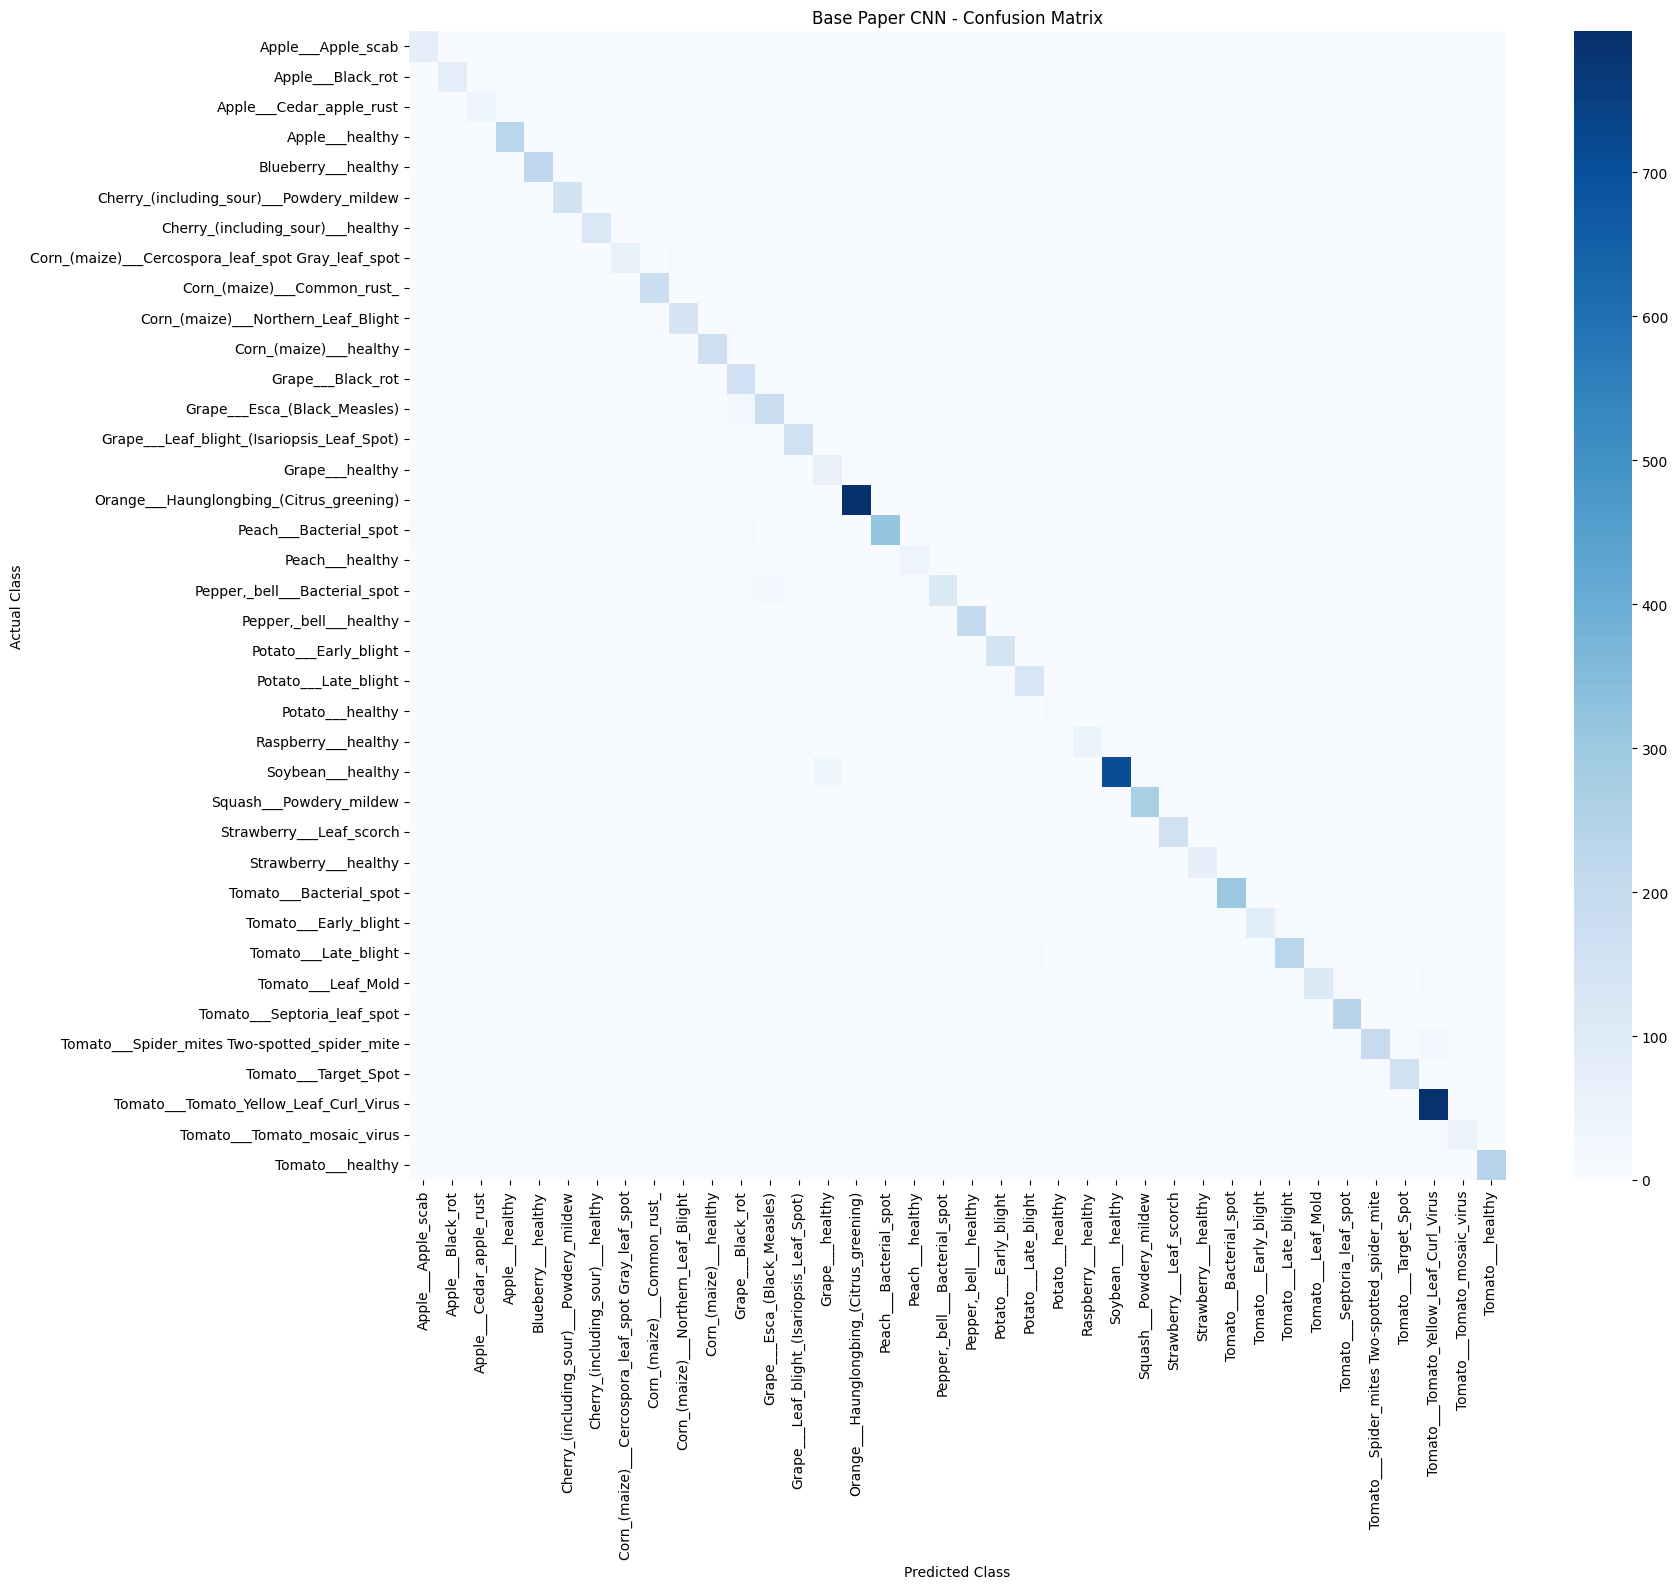

In [107]:
cm = confusion_matrix(

    y_true,

    y_pred
)


plt.figure(

    figsize=(18, 16)
)


sns.heatmap(

    cm,

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Base Paper CNN - Confusion Matrix"
)


plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()

In [108]:
macro_roc_auc = roc_auc_score(

    y_true,

    y_prob,

    multi_class="ovr",

    average="macro"
)


print(
    f"Macro ROC-AUC: "
    f"{macro_roc_auc:.4f}"
)

Macro ROC-AUC: 0.9984


In [109]:
results = pd.DataFrame({

    "Model": [
        "Base Paper CNN"
    ],

    "Test Accuracy": [
        test_accuracy
    ],

    "Macro Precision": [
        precision
    ],

    "Macro Recall": [
        recall
    ],

    "Macro F1": [
        f1
    ],

    "Macro ROC-AUC": [
        macro_roc_auc
    ],

    "Parameters": [
        trainable_parameters
    ]
})


results

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC,Parameters
0,Base Paper CNN,91.590965,0.898383,0.890427,0.889011,0.998413,210418


In [64]:
def predict_image(

    image_path,

    model,

    class_names,

    device
):


    image = Image.open(

        image_path

    ).convert("RGB")


    input_tensor = eval_transform(

        image

    ).unsqueeze(0).to(device)


    model.eval()


    with torch.no_grad():

        output = model(

            input_tensor

        )


        probabilities = torch.softmax(

            output,

            dim=1

        )


        confidence, prediction = torch.max(

            probabilities,

            dim=1

        )


    predicted_class = class_names[
        prediction.item()
    ]


    confidence = (
        confidence.item()
        * 100
    )


    plt.figure(
        figsize=(6, 6)
    )


    plt.imshow(image)

    plt.axis("off")


    plt.title(

        f"Prediction: "
        f"{predicted_class}\n"
        f"Confidence: "
        f"{confidence:.2f}%"
    )


    plt.show()


    return (

        predicted_class,

        confidence
    )

In [114]:
print(model)

BasePaperCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (se2): SEBlock(
    (pool): AdaptiveAvgPool2d(output_size=1)
    (fc): Sequential(
      (0): Linear(in_features=64, out_features=4, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=4, out_features=64, bias=True)
      (3): Sigmoid()
    )
  )
  (residual2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bi

In [115]:
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        print(name, "->", module)

block1.0 -> Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
conv2.0 -> Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
residual2.0 -> Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
conv3.depthwise -> Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
conv3.pointwise -> Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
residual3.0 -> Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
attention.0 -> Conv2d(224, 224, kernel_size=(1, 1), stride=(1, 1), bias=False)
attention.3 -> Conv2d(224, 224, kernel_size=(1, 1), stride=(1, 1))


In [117]:
class GradCAM:

    def __init__(

        self,

        model,

        target_layer

    ):

        self.model = model

        self.target_layer = target_layer

        self.activations = None

        self.gradients = None


        self.forward_hook = (

            target_layer.register_forward_hook(

                self.save_activation

            )
        )


        self.backward_hook = (

            target_layer.register_full_backward_hook(

                self.save_gradient

            )
        )


    def save_activation(

        self,

        module,

        input,

        output

    ):

        self.activations = output


    def save_gradient(

        self,

        module,

        grad_input,

        grad_output

    ):

        self.gradients = grad_output[0]


    def generate(

        self,

        input_tensor,

        class_index=None

    ):

        self.model.eval()


        output = self.model(

            input_tensor

        )


        if class_index is None:

            class_index = (

                output.argmax(

                    dim=1

                ).item()

            )


        self.model.zero_grad()


        score = output[

            0,

            class_index

        ]


        score.backward()


        activations = (

            self.activations

        )


        gradients = (

            self.gradients

        )


        weights = gradients.mean(

            dim=(2, 3),

            keepdim=True

        )


        cam = (

            weights * activations

        ).sum(

            dim=1

        )


        cam = torch.relu(

            cam

        )


        cam = cam.squeeze().detach().cpu().numpy()


        cam = (

            cam - cam.min()

        ) / (

            cam.max()

            - cam.min()

            + 1e-8

        )


        return (

            cam,

            class_index

        )

In [118]:
import cv2


def show_gradcam(

    image_path,

    model,

    gradcam,

    class_names,

    device

):


    image = Image.open(

        image_path

    ).convert("RGB")


    original = np.array(

        image

    )


    input_tensor = eval_transform(

        image

    ).unsqueeze(0).to(device)


    cam, class_index = gradcam.generate(

        input_tensor

    )


    cam = cv2.resize(

        cam,

        (

            original.shape[1],

            original.shape[0]

        )

    )


    heatmap = np.uint8(

        255 * cam

    )


    heatmap = cv2.applyColorMap(

        heatmap,

        cv2.COLORMAP_JET

    )


    heatmap = cv2.cvtColor(

        heatmap,

        cv2.COLOR_BGR2RGB

    )


    overlay = (

        0.5 * original

        + 0.5 * heatmap

    ).astype(np.uint8)


    plt.figure(

        figsize=(15, 5)

    )


    plt.subplot(

        1, 3, 1

    )

    plt.imshow(

        original

    )

    plt.title(

        "Original Image"

    )

    plt.axis("off")


    plt.subplot(

        1, 3, 2

    )

    plt.imshow(

        cam,

        cmap="jet"

    )

    plt.title(

        "Grad-CAM"

    )

    plt.axis("off")


    plt.subplot(

        1, 3, 3

    )

    plt.imshow(

        overlay

    )

    plt.title(

        f"Prediction:\n"
        f"{class_names[class_index]}"
    )

    plt.axis("off")


    plt.tight_layout()

    plt.show()

In [120]:
# Find the last Conv2d layer automatically for Grad-CAM

conv_layers = []

for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        conv_layers.append((name, module))

print("Convolutional layers:")

for name, module in conv_layers:
    print(name)

# Use the last convolutional layer
target_layer_name, target_layer = conv_layers[-1]

print("\nGrad-CAM target layer:")
print(target_layer_name)
print(target_layer)

Convolutional layers:
block1.0
conv2.0
residual2.0
conv3.depthwise
conv3.pointwise
residual3.0
attention.0
attention.3

Grad-CAM target layer:
attention.3
Conv2d(224, 224, kernel_size=(1, 1), stride=(1, 1))


In [121]:
test_index = test_indices[0]

test_image_path = dataset.samples[
    test_index
][0]

print(
    test_image_path
)

/content/plantvillage/plantvillage dataset/color/Tomato___Late_blight/747a2385-2777-445a-b215-7a14a5c0135c___RS_Late.B 7111.JPG


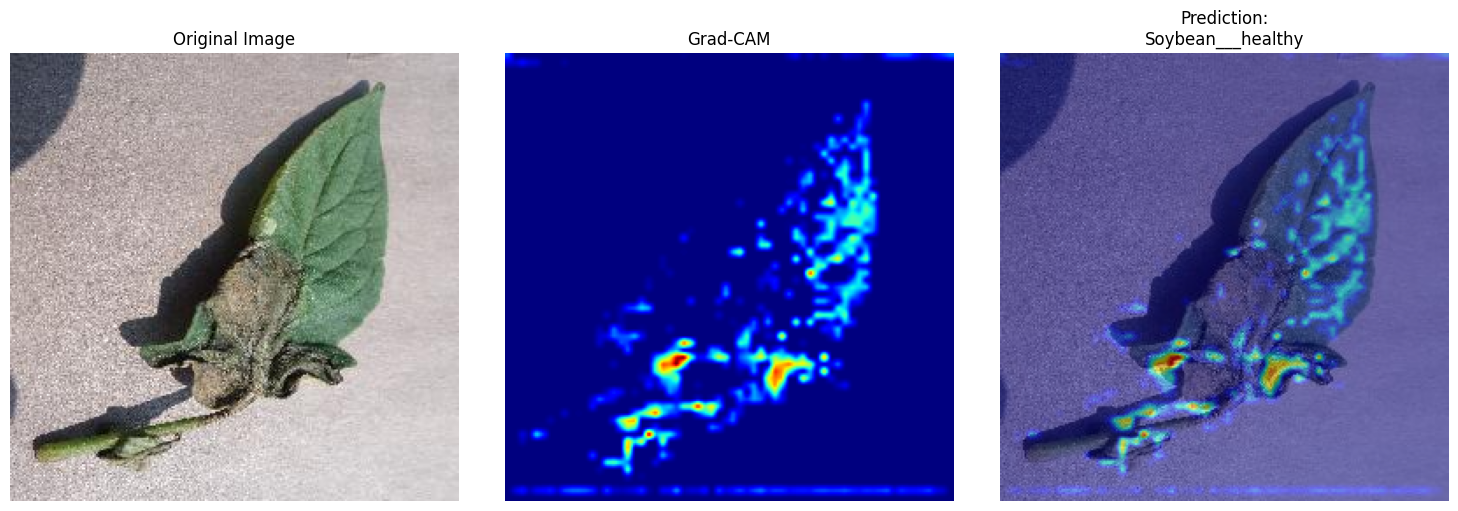

In [122]:
show_gradcam(

    test_image_path,

    model,

    gradcam,

    class_names,

    device
)

In [123]:
torch.save(

    model.state_dict(),

    "/content/base_paper_cnn_final.pth"

)

print(
    "✓ Final model saved"
)

✓ Final model saved


In [124]:
print("Best validation accuracy:", best_val_accuracy)

print("Training accuracies:")
for i, acc in enumerate(history["train_acc"]):
    print(f"Epoch {i+1}: {acc:.2f}%")

print("\nValidation accuracies:")
for i, acc in enumerate(history["val_acc"]):
    print(f"Epoch {i+1}: {acc:.2f}%")

print(f"\nTest accuracy: {test_accuracy:.2f}%")

Best validation accuracy: 90.44930027007119
Training accuracies:
Epoch 1: 52.38%
Epoch 2: 73.71%
Epoch 3: 80.15%
Epoch 4: 84.22%
Epoch 5: 86.56%

Validation accuracies:
Epoch 1: 75.07%
Epoch 2: 84.40%
Epoch 3: 87.88%
Epoch 4: 87.47%
Epoch 5: 90.45%

Test accuracy: 91.59%


In [125]:
print("Train accuracy:", history["train_acc"][-1])
print("Validation accuracy:", history["val_acc"][-1])
print("Best validation:", best_val_accuracy)
print("Test accuracy:", test_accuracy)

Train accuracy: 86.55986110014994
Validation accuracy: 90.44930027007119
Best validation: 90.44930027007119
Test accuracy: 91.59096489074392
